# CISI Evaluation — BM25 vs. TF-IDF (Real Metrics)

##  Imports & configuration

In [12]:
import re, math, os
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
nltk.download('stopwords', quiet=True)

STEMMER = PorterStemmer()
STOP    = set(stopwords.words('english'))

CISI_DIR = 'cisi'   
K        = 10       # cutoff for Precision@K

##  CISI parsers

In [13]:
def _merge_fields(path):
    merged = ''
    with open(path, encoding='utf-8') as f:
        for line in f:
            merged += ('\n' + line.strip()) if line.startswith('.') else (' ' + line.strip())
    return merged

def _parse_TW(path):
    out, cur, buf = {}, None, ''
    for line in _merge_fields(path).split('\n'):
        line = line.strip()
        if not line:
            continue
        if line.startswith('.I'):
            if cur is not None:
                out[cur] = buf.strip()
            cur = str(int(line[2:].strip()))
            buf = ''
        elif line.startswith('.T') or line.startswith('.W'):
            buf += ' ' + line[2:].strip()
        # .A / .X / .B / .K etc. ignored
    if cur is not None:
        out[cur] = buf.strip()
    return out

def load_cisi_docs(path):    return _parse_TW(path)
def load_cisi_queries(path): return _parse_TW(path)

def load_cisi_rel(path):
    rel = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            p = line.split()
            if len(p) < 2:
                continue
            rel.setdefault(str(int(p[0])), set()).add(str(int(p[1])))
    return rel

##  Load the collection

In [14]:
docs    = load_cisi_docs(os.path.join(CISI_DIR, 'CISI.ALL'))
queries = load_cisi_queries(os.path.join(CISI_DIR, 'CISI.QRY'))
rel     = load_cisi_rel(os.path.join(CISI_DIR, 'CISI.REL'))

print(f'Documents loaded:        {len(docs)}')
print(f'Queries loaded:          {len(queries)}')
print(f'Queries with judgments:  {len(rel)}   (only these are scored)')

Documents loaded:        1460
Queries loaded:          112
Queries with judgments:  76   (only these are scored)


##  Build the inverted index + document norms

In [15]:
def preprocess(text):
    toks = re.findall(r'\w+', text.lower())
    return [STEMMER.stem(t) for t in toks if t not in STOP]

index, doc_lengths = {}, {}
for did, text in docs.items():
    toks = preprocess(text)
    doc_lengths[did] = len(toks)
    for t in toks:
        if t not in index:
            index[t] = {}
        index[t][did] = index[t].get(did, 0) + 1

N      = len(doc_lengths)
AVG_DL = sum(doc_lengths.values()) / N

# TF-IDF vector norm per document (for TRUE cosine)
_nsq = {d: 0.0 for d in doc_lengths}
for term, postings in index.items():
    idf = math.log10(N / len(postings))
    for d, tf in postings.items():
        w = (1 + math.log10(tf)) * idf
        _nsq[d] += w * w
DOC_NORMS = {d: math.sqrt(s) if s > 0 else 0.0 for d, s in _nsq.items()}

print(f'Vocabulary size:   {len(index)}')
print(f'Avg doc length:    {AVG_DL:.2f} tokens')

Vocabulary size:   6066
Avg doc length:    72.44 tokens


##  Retrieval models (identical scoring to `main.ipynb`)

In [16]:
def get_bm25(query_tokens):
    scores, k1, b = {}, 1.5, 0.75
    for token in query_tokens:
        s = STEMMER.stem(token)
        if s in index:
            df  = len(index[s])
            idf = math.log((N - df + 0.5) / (df + 0.5) + 1)
            for d, tf in index[s].items():
                dl    = doc_lengths[d]
                denom = tf + k1 * (1 - b + b * (dl / AVG_DL))
                scores[d] = scores.get(d, 0) + idf * (tf * (k1 + 1)) / denom
    return [d for d, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)]

def get_tfidf(query_tokens):   # TRUE cosine
    qw = {}
    for token in set(query_tokens):
        s = STEMMER.stem(token)
        if s in index:
            idf   = math.log10(N / len(index[s]))
            qw[s] = (1 + math.log10(query_tokens.count(token))) * idf
    qnorm = math.sqrt(sum(w * w for w in qw.values())) or 1.0
    scores = {}
    for s, wq in qw.items():
        idf = math.log10(N / len(index[s]))
        for d, tf in index[s].items():
            wd = (1 + math.log10(tf)) * idf
            scores[d] = scores.get(d, 0) + wq * wd
    ranked = [(d, dot / (qnorm * DOC_NORMS[d])) for d, dot in scores.items() if DOC_NORMS[d] > 0]
    return [d for d, _ in sorted(ranked, key=lambda x: x[1], reverse=True)]


##  Evaluation metrics

In [17]:
def precision_at_k(ret, rels, k):
    topk = ret[:k]
    return sum(1 for d in topk if d in rels) / k if topk else 0.0

def average_precision(ret, rels):
    if not rels:
        return 0.0
    hits, ap = 0, 0.0
    for i, d in enumerate(ret, 1):
        if d in rels:
            hits += 1
            ap   += hits / i
    return ap / len(rels)

def reciprocal_rank(ret, rels):
    for i, d in enumerate(ret, 1):
        if d in rels:
            return 1.0 / i
    return 0.0


##  Run the evaluation

In [18]:
def evaluate(ranker, k=K):
    aps, rrs, pks = [], [], []
    for qid, qtext in queries.items():
        if qid not in rel:
            continue
        rels   = rel[qid]
        toks   = re.findall(r'\w+', qtext.lower())   # ranker stems internally
        ranked = ranker(toks)
        aps.append(average_precision(ranked, rels))
        rrs.append(reciprocal_rank(ranked, rels))
        pks.append(precision_at_k(ranked, rels, k))
    n = len(aps)
    return {'queries': n,
            'MAP':  sum(aps) / n,
            'MRR':  sum(rrs) / n,
            f'P@{k}': sum(pks) / n}

results = {'BM25': evaluate(get_bm25), 'TF-IDF (cosine)': evaluate(get_tfidf)}

print(f"{'Model':<18}{'Queries':>9}{'MAP':>10}{'MRR':>10}{('P@'+str(K)):>10}")
print('-' * 57)
for name, r in results.items():
    print(f"{name:<18}{r['queries']:>9}{r['MAP']:>10.4f}{r['MRR']:>10.4f}{r['P@'+str(K)]:>10.4f}")

Model               Queries       MAP       MRR      P@10
---------------------------------------------------------
BM25                     76    0.2322    0.6532    0.3697
TF-IDF (cosine)          76    0.1916    0.5596    0.2921


##  Bar chart 

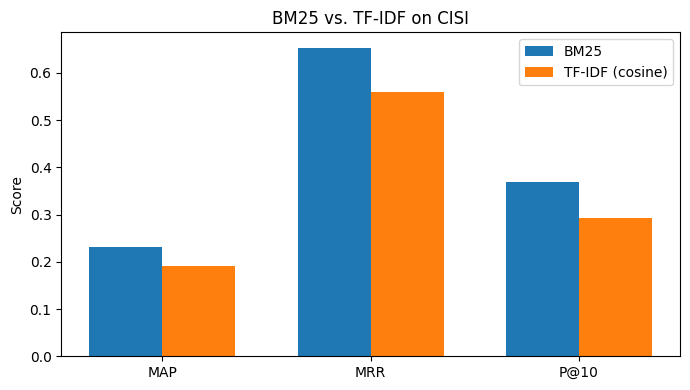

In [19]:
import matplotlib.pyplot as plt

metrics = ['MAP', 'MRR', f'P@{K}']
models  = list(results.keys())
x       = range(len(metrics))
width   = 0.35

plt.figure(figsize=(7, 4))
for i, m in enumerate(models):
    vals = [results[m][k] for k in metrics]
    plt.bar([p + i * width for p in x], vals, width, label=m)
plt.xticks([p + width / 2 for p in x], metrics)
plt.ylabel('Score')
plt.title('BM25 vs. TF-IDF on CISI')
plt.legend()
plt.tight_layout()
plt.show()

